#### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, LocallyLinearEmbedding

import sys
sys.path.append("../src")
from column_aliases import COLUMN_ALIASES

plt.style.use("seaborn-v0_8-whitegrid")
INPUT_FILE = "../data/processed/selected_features.csv"
print("Setup abgeschlossen.")


Setup abgeschlossen.


#### 2. Daten laden

In [2]:
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}, NaN gesamt: {df.isna().sum().sum()}")


Shape: (1142, 13), NaN gesamt: 0


#### 3. Standardisierung

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df)
print(f"Feature-Matrix: {X.shape}")


Feature-Matrix: (1142, 13)


#### 4. PCA – Scree-Plot

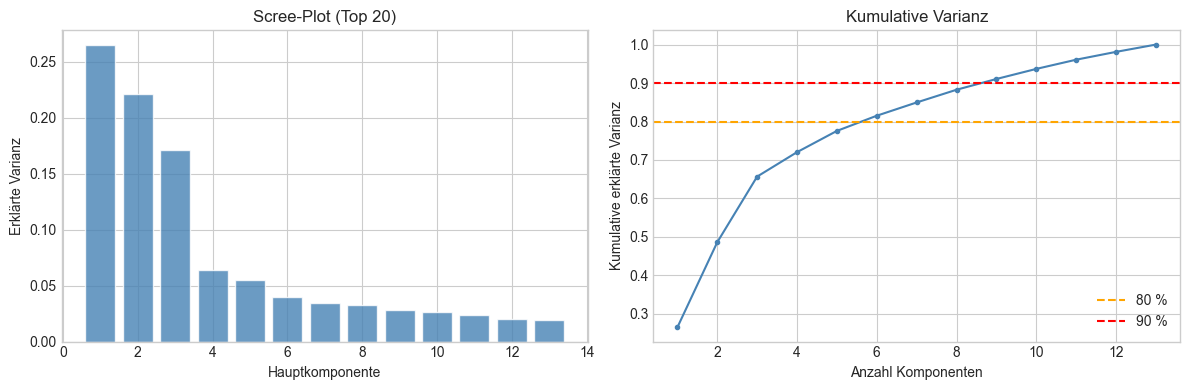

Komponenten für 80 % Varianz: 6
Komponenten für 90 % Varianz: 9


In [4]:
pca_full = PCA()
pca_full.fit(X)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(20, len(explained))
axes[0].bar(range(1, n_show + 1), explained[:n_show], color="steelblue", alpha=0.8)
axes[0].set_xlabel("Hauptkomponente")
axes[0].set_ylabel("Erklärte Varianz")
axes[0].set_title("Scree-Plot (Top 20)")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker=".", color="steelblue")
axes[1].axhline(0.8, color="orange", linestyle="--", label="80 %")
axes[1].axhline(0.9, color="red", linestyle="--", label="90 %")
axes[1].set_xlabel("Anzahl Komponenten")
axes[1].set_ylabel("Kumulative erklärte Varianz")
axes[1].set_title("Kumulative Varianz")
axes[1].legend()

plt.tight_layout()
plt.savefig("../documentation/figures/dimension_reduction/pca_scree.png", dpi=150)
plt.show()

n_80 = np.argmax(cumulative >= 0.80) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1
print(f"Komponenten für 80 % Varianz: {n_80}")
print(f"Komponenten für 90 % Varianz: {n_90}")


#### 5. PCA – 2D-Projektion

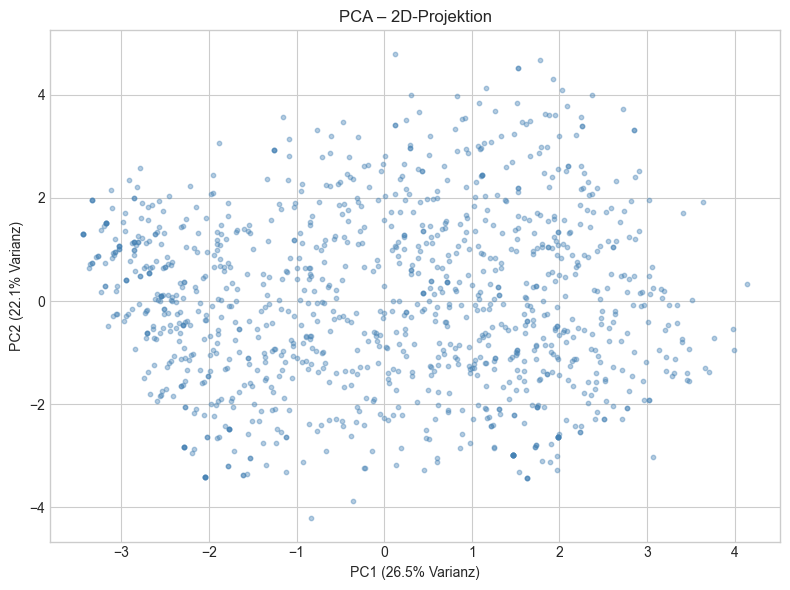

In [5]:
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=10, color="steelblue")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} Varianz)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} Varianz)")
ax.set_title("PCA – 2D-Projektion")
plt.tight_layout()
plt.savefig("../documentation/figures/dimension_reduction/pca_2d.png", dpi=150)
plt.show()


#### 6. MDS – 2D-Projektion

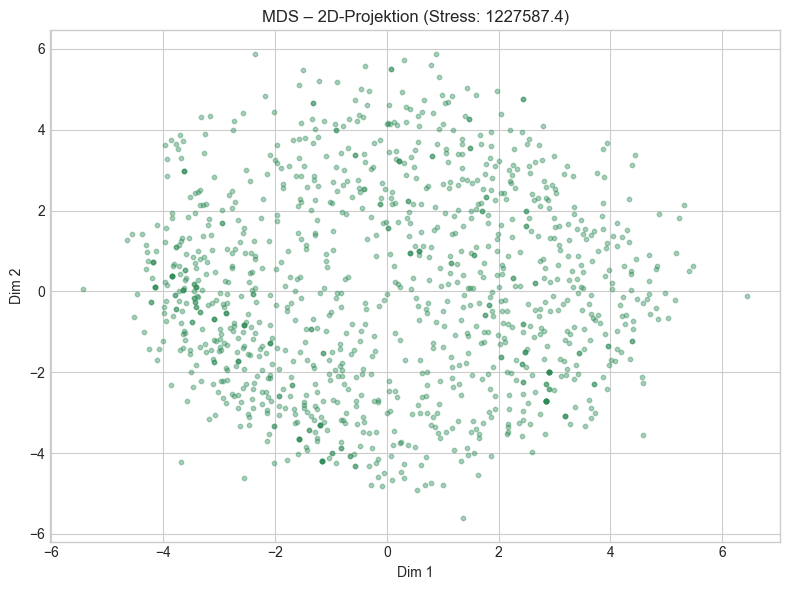

Stress: 1227587.4373


In [6]:
mds = MDS(n_components=2, random_state=42, n_init=2, max_iter=200, init='random')
X_mds = mds.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_mds[:, 0], X_mds[:, 1], alpha=0.4, s=10, color="seagreen")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_title(f"MDS – 2D-Projektion (Stress: {mds.stress_:.1f})")
plt.tight_layout()
plt.savefig("../documentation/figures/dimension_reduction/mds_2d.png", dpi=150)
plt.show()

print(f"Stress: {mds.stress_:.4f}")


#### 7. LLE – 2D-Projektion

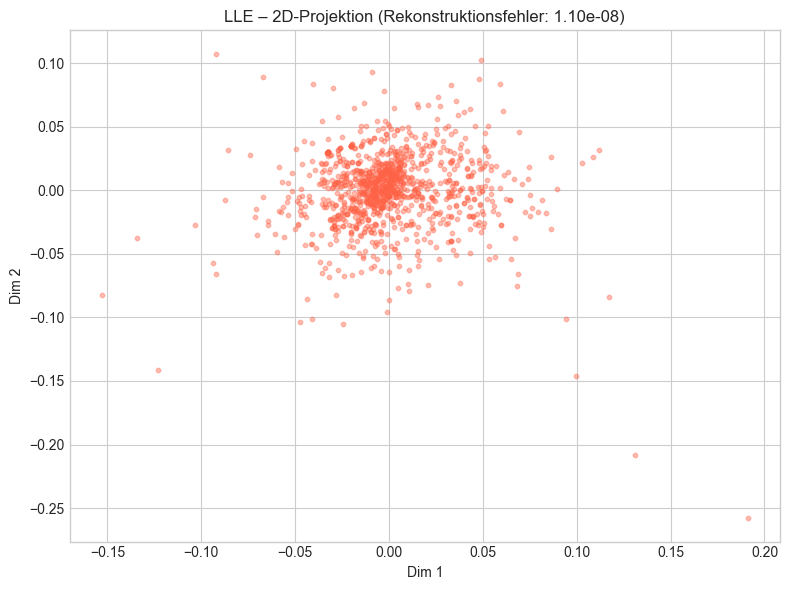

Rekonstruktionsfehler: 0.000000


In [7]:
lle = LocallyLinearEmbedding(n_neighbors=15, n_components=2, random_state=42)
X_lle = lle.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_lle[:, 0], X_lle[:, 1], alpha=0.4, s=10, color="tomato")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_title(f"LLE – 2D-Projektion (Rekonstruktionsfehler: {lle.reconstruction_error_:.2e})")
plt.tight_layout()
plt.savefig("../documentation/figures/dimension_reduction/lle_2d.png", dpi=150)
plt.show()

print(f"Rekonstruktionsfehler: {lle.reconstruction_error_:.6f}")


#### 8. Vergleich der Verfahren

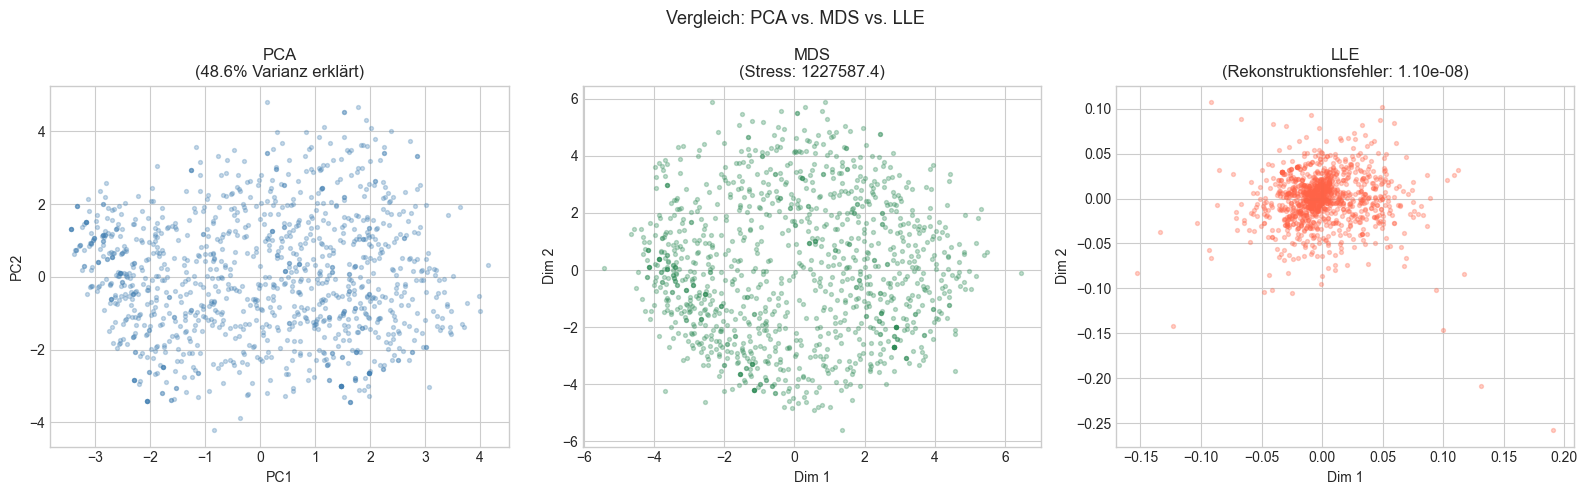

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=8, color="steelblue")
axes[0].set_title(f"PCA\n({pca2.explained_variance_ratio_.sum():.1%} Varianz erklärt)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_mds[:, 0], X_mds[:, 1], alpha=0.3, s=8, color="seagreen")
axes[1].set_title(f"MDS\n(Stress: {mds.stress_:.1f})")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

axes[2].scatter(X_lle[:, 0], X_lle[:, 1], alpha=0.3, s=8, color="tomato")
axes[2].set_title(f"LLE\n(Rekonstruktionsfehler: {lle.reconstruction_error_:.2e})")
axes[2].set_xlabel("Dim 1"); axes[2].set_ylabel("Dim 2")

plt.suptitle("Vergleich: PCA vs. MDS vs. LLE", fontsize=13)
plt.tight_layout()
plt.savefig("../documentation/figures/dimension_reduction/dimred_vergleich.png", dpi=150)
plt.show()
